# Housing Prices


https://www.kaggle.com/datasets/yasserh/housing-prices-dataset


Bảng có 545 căn nhà và 13 cột. Cột price là giá cần quan sát. Các cột còn lại là thông tin của nhà: diện tích, số phòng ngủ, số phòng tắm, số tầng, chỗ đậu xe, và vài đặc điểm như gần đường chính, có tầng hầm, có máy lạnh.


## 1. Đọc dữ liệu


In [64]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/Housing.csv")
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 2. Xem tổng quan

describe cho số lượng, trung bình, độ lệch, giá trị nhỏ nhất và lớn nhất của các cột số.

columns in tên đủ 13 cột. Ngoài các cột số còn có mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea và furnishingstatus. Những cột này ghi chữ yes hoặc no, hoặc mức nội thất.


In [65]:
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [66]:
df.columns


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

## 3. Các mức giá khác nhau

unique lấy từng mức giá, mỗi mức một lần. sum cộng các mức đó lại.

Kết quả là 1150235940. Đây là tổng các mức giá khác nhau, không phải tổng giá của cả 545 căn, vì nhiều căn trùng một mức giá.


In [67]:
df["price"].unique().sum()  

1150235940

## 4. Xử lý inf và NaN

inf là vô cực. Nếu một ô bị inf, replace đổi ô đó thành NaN. dropna rồi bỏ những hàng không có price, vì hàng không có giá thì không xem được phân phối giá.

inplace=True sửa thẳng trên df. Bộ này không có inf và không thiếu price, nên sau bước này vẫn còn 545 hàng. Hai lệnh vẫn nên chạy, đúng thứ tự trên lớp.


In [68]:
# kiểm tra các giá trị vô hạn và thay thế bằng nan
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# xử lý giá trị Nan
df.dropna(subset=["price"], inplace=True)

df.shape


(545, 13)

## 5. Diện tích và giá

Biểu đồ này đặt area trên trục ngang và price trên trục dọc. Mỗi chấm là một căn nhà.

Nhà rộng hơn thường đắt hơn, nhưng đám mây rất dày. Cùng một khoảng diện tích, giá vẫn trải từ vài triệu đến hơn mười triệu. Diện tích chưa cố định được giá.

Trục dọc ghi 1e7 nghĩa là đơn vị mười triệu. Mức 0.4 trên hình là khoảng 4 triệu.


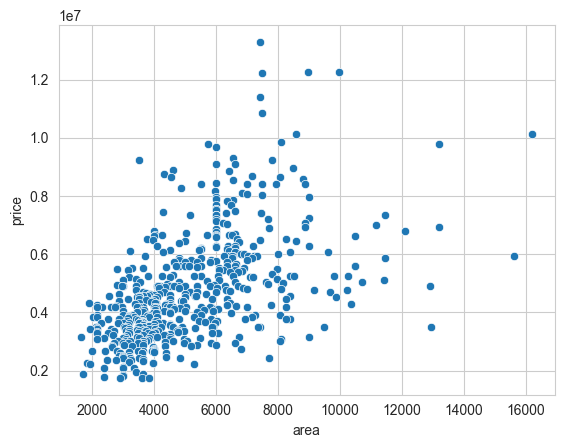

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

sns.scatterplot(data=df, x="area", y="price")
plt.show()


## 6. số phòng ngủ

Cùng biểu đồ diện tích và giá, thêm hue=bedrooms. Mỗi số phòng ngủ một màu.

Màu không tách thành từng cụm riêng. Nhà 2, 3, 4 phòng ngủ nằm trộn trong cùng vùng diện tích và giá. Số phòng ngủ có liên quan đến giá, nhưng không tự nó vẽ thành một đường thẳng.


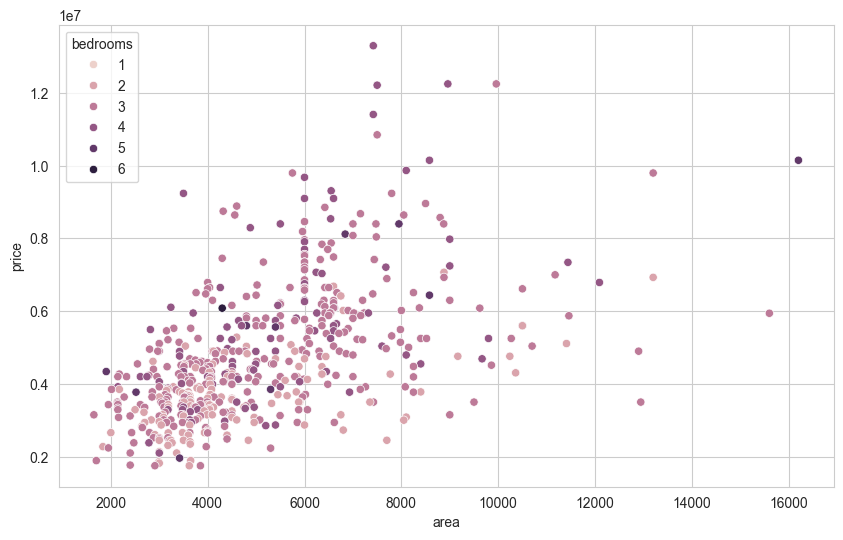

In [70]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="area", y="price", hue="bedrooms")
plt.show()


## 7. Phân phối giá

Histogram chia giá thành 30 cột. Cột cao là khoảng giá có nhiều nhà. Đường cong kde vẽ dạng phân phối mượt lên trên các cột.

Phần lớn nhà nằm khoảng 3 đến 6 triệu. Phía giá cao, từ khoảng 8 triệu trở lên, cột thấp dần. Vài căn rất đắt nằm riêng ở đuôi bên phải, gần 12 đến 13 triệu.


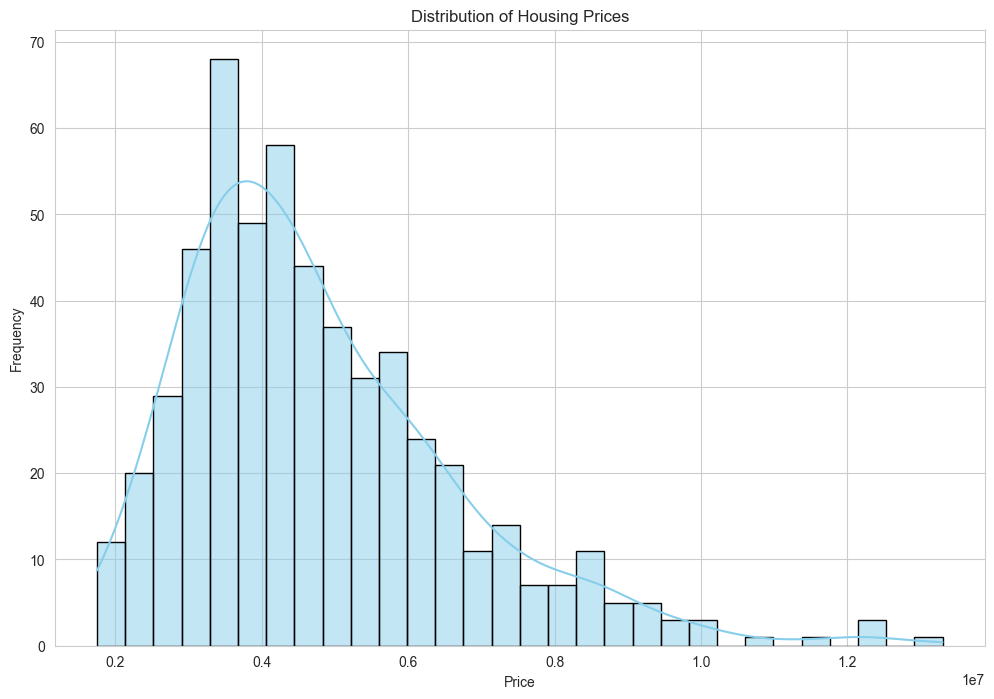

In [71]:
# vẽ biểu đồ
plt.figure(figsize=(12, 8))
sns.histplot(df["price"], bins=30, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution of Housing Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


## 8. Đếm số phòng ngủ

countplot đếm số căn theo bedrooms. Cột cao nhất là 3 phòng ngủ. Tiếp theo là 2 phòng, rồi 4 phòng. Nhà 1, 5 và 6 phòng ngủ rất ít.


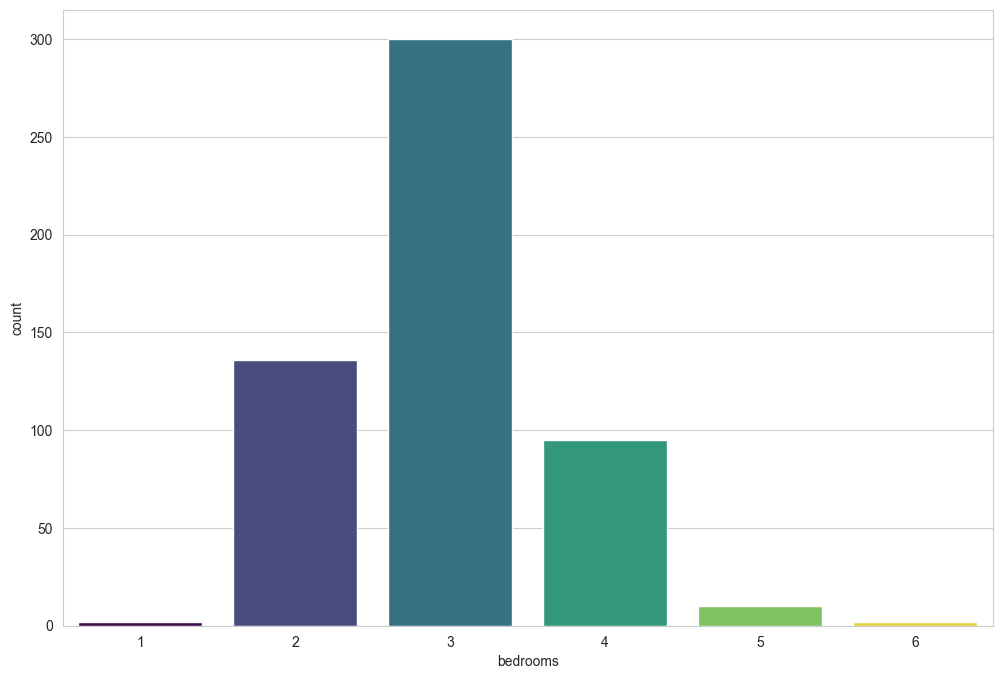

In [72]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x="bedrooms", hue="bedrooms", palette="viridis", legend=False)
plt.show()


## 9. Chọn cột cho mô hình

Lớp chỉ giữ bốn cột: area, bedrooms, bathrooms và price. Ba cột đầu là feature. price là label.

Các cột chữ như mainroad, basement, airconditioning chưa đưa vào mô hình ở bước này. Sau khi chọn, bảng còn 545 hàng và 4 cột.


In [73]:
df = df[["area", "bedrooms", "bathrooms", "price"]]
df


,area,bedrooms,bathrooms,price
0,7420,4,2,13300000
1,8960,4,4,12250000
2,9960,3,2,12250000
3,7500,4,2,12215000
4,7420,4,1,11410000
...,...,...,...,...
540,3000,2,1,1820000
541,2400,3,1,1767150
542,3620,2,1,1750000
543,2910,3,1,1750000


## 10. Tách feature, label, rồi chia tập train và tập test

X là ba cột dùng để đoán. y là price. X.shape ra (545, 3): 545 căn, 3 feature.

train_test_split để lại 80% hàng cho việc học và 20% hàng để kiểm tra. test_size = 0.2 là 20% đó.

random_state giữ cách chia không đổi mỗi lần chạy.

- 42 là số rất hay được dùng. 
- 0 là cách chọn đơn giản.
- 123 là một số bất kỳ, vẫn dùng được.
- 2024 có thể lấy theo năm.

Đổi random_state thì tập kiểm tra đổi, nên MSE và R² cũng đổi một chút. Bài này giữ 42 như trên lớp.


In [74]:
X = df[["area", "bedrooms", "bathrooms"]]
y = df["price"]
X.shape


(545, 3)

In [75]:
# random_state=42    Rất phổ biến, nhắc tới The Hitchhiker's Guide to the Galaxy
# random_state=0     Đơn giản
# random_state=123   Bất kỳ số nào cũng được
# random_state=2026  Có thể dùng năm hiện tại
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 11. Train

LinearRegression tạo mô hình đường thẳng với nhiều feature. fit học weight và bias trên tập học, không dùng tập kiểm tra.

$$\hat{y} = w_1 \times area + w_2 \times bedrooms + w_3 \times bathrooms + b$$

w1, w2, w3 nằm trong coef_. b là intercept_.


In [76]:
model = LinearRegression()
model.fit(X_train, y_train)
model


LinearRegression()

## 12. Đo sai số trên tập kiểm tra

predict tính giá đoán cho những căn mô hình chưa học. Ba số để đọc kết quả là MSE, RMSE và R².

### MSE

MSE là trung bình của từng khoảng lệch, sau khi bình phương.

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

y là giá thật. ŷ là giá đoán. n là số căn trong tập kiểm tra.

Bình phương làm số âm và số dương đều thành số dương, rồi cộng lại. Giá nhà tính bằng triệu, bình phương xong MSE thành hàng nghìn tỷ. Không đọc MSE như số tiền bị lệch.

### RMSE

RMSE là căn bậc hai của MSE. Căn bậc hai đưa số đã bình phương trở lại đơn vị tiền, cùng đơn vị với giá nhà.

$$RMSE = \sqrt{MSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

RMSE bằng 0 là mọi căn đều đoán trúng giá thật. RMSE càng nhỏ thì khoảng lệch tiền càng nhỏ.

Ô code in RMSE khoảng 1,658,325. Nghĩa là trên tập kiểm tra, mỗi căn có thể lệch khoảng 1,66 triệu. Giá trung bình trong data khoảng 4,77 triệu, nên lệch 1,66 triệu vẫn còn lớn. Ở mục 16, khi đưa thêm các cột còn lại, RMSE giảm xuống khoảng 1,324,507. Lệch tiền nhỏ hơn, mô hình sát giá hơn.

### R²

R² cho biết ba cột area, bedrooms và bathrooms giải thích được bao nhiêu phần sự chênh lệch của giá.

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

ȳ là giá trung bình.

R² bằng 1 là đoán sát từng căn. R² bằng 0 là không hơn cách đoán mọi căn bằng giá trung bình.

### Nhìn ba số thì nói được gì

Chạy ô này in MSE khoảng 2750040479309 và R² khoảng 0.456. Màn hình trên lớp in MSE khoảng 2718519113733 và R² khoảng 0.462. Hai lần lệch một chút.

Cách nói với sinh viên: mô hình có học được hướng của giá, vì R² khoảng 0.46, tức giải thích khoảng 46% phần chênh lệch. Phần còn lại đến từ những cột chưa đưa vào, như số tầng, chỗ đậu xe, gần đường chính. Đồng thời từng căn vẫn có thể lệch khoảng 1,66 triệu. Đó là lý do các chấm trên biểu đồ phía dưới còn nằm xa đường đỏ.


In [77]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = mse ** 0.5
print(mse, r2)
print("RMSE =", f"{rmse:,.0f}")


2750040479309.052 0.45592991188724463
RMSE = 1,658,325


## 13. Giá thật và giá đoán

Mỗi chấm xanh là một căn trong tập kiểm tra. Trục ngang là giá thật. Trục dọc là giá mô hình đoán. Chú thích của chấm là Du doan mo hinh.

Đường đỏ có chú thích Duong, nghĩa là đường hồi quy. Đó là đường thẳng đi qua đám điểm. Vùng hồng quanh đường đỏ là khoảng dao động của đường đó, do regplot vẽ thêm.

Chấm càng sát đường đỏ thì giá đoán càng gần giá thật. Đám điểm còn tán ra hai bên, đúng với R² khoảng 0.46: mô hình bắt được hướng của giá, nhưng chưa sát từng căn.


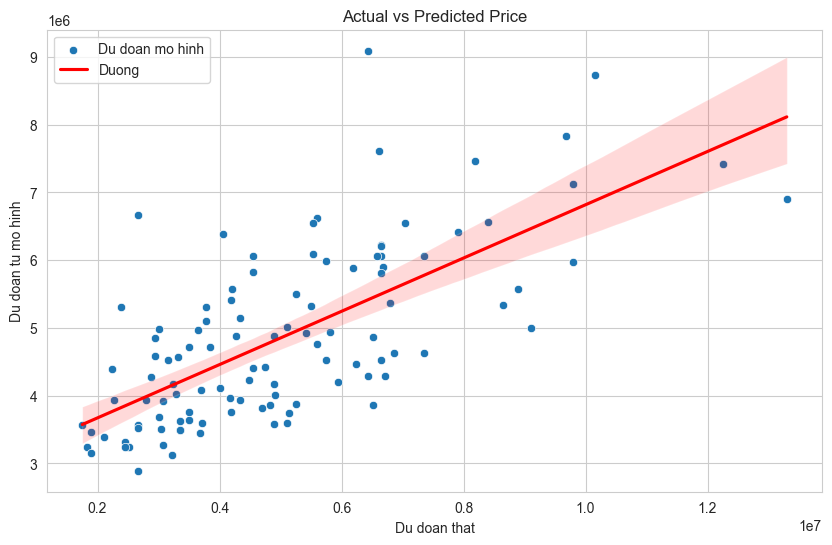

In [78]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, label="Du doan mo hinh")
sns.regplot(x=y_test, y=y_pred, scatter=False, color="red", label="Duong")  # Đường hồi quy
plt.xlabel("Du doan that")
plt.ylabel("Du doan tu mo hinh")
plt.title("Actual vs Predicted Price")
plt.legend()
plt.grid(True)
plt.show()


## 14. Lưu mô hình

joblib.dump ghi mô hình đã học ra file Linear.pkl. Weight và bias nằm trong file đó.

Lần sau muốn đoán giá một căn nhà thì đọc file này lên, không cần fit lại từ đầu.


In [79]:
import joblib

joblib.dump(model, "Linear.pkl")
print("Da luu Linear.pkl")


Da luu Linear.pkl


## 15. Testcase

joblib.load đọc Linear.pkl trở lại thành mô hình. Weight và bias vẫn là số đã học, nên không cần fit lại.

Căn thử có area = 5000, bedrooms = 3, bathrooms = 2. Ba số này đi vào đúng ba cột lúc huấn luyện.

Giá đoán khoảng 5,712,050. Có thể kiểm lại bằng công thức:

$$\hat{y} = 345.47 \times 5000 + 360198 \times 3 + 1422320 \times 2 + 59485$$

Ô thứ hai lấy một căn trong tập kiểm tra. Căn này không nằm trong tập học. In giá thật cạnh giá đoán để thấy mô hình vừa lưu vẫn đoán được.


In [80]:
import joblib
import pandas as pd

model_loaded = joblib.load("Linear.pkl")

nha_thu = pd.DataFrame({
    "area": [5000],
    "bedrooms": [3],
    "bathrooms": [2],
})
gia = model_loaded.predict(nha_thu)[0]
print("area = 5000, bedrooms = 3, bathrooms = 2")
print("Predicted price =", f"{gia:,.0f}")


area = 5000, bedrooms = 3, bathrooms = 2
Predicted price = 5,712,050


In [81]:
mot_can = X_test.iloc[[0]]
gia_that = y_test.iloc[0]
gia_doan = model_loaded.predict(mot_can)[0]
print(mot_can)
print("Real price =", f"{gia_that:,.0f}")
print("Predicted price =", f"{gia_doan:,.0f}")


     area  bedrooms  bathrooms
316  5900         4          2
Real price = 4,060,000
Predicted price = 6,383,168


Nhận xét 

Căn vừa in có area = 5900, bedrooms = 4, bathrooms = 2. Giá thật là 4,060,000. Giá đoán là 6,383,168.

Ba cột area, bedrooms, bathrooms chỉ thấy một căn khá rộng, nên đoán theo mức giá của nhóm nhà rộng. Những căn diện tích khoảng 5500 đến 6500, cùng 4 phòng ngủ và 2 phòng tắm, có giá trung vị khoảng 7,070,000. Căn này rẻ hơn nhóm đó vì nó không gần đường chính, không có máy lạnh, chưa có nội thất, và không nằm khu được ưa chuộng. Những cột này đang có trong data, nhưng chưa được đưa vào X.


## 16. Huấn luyện lại và đưa các cột vào

Ba cột area, bedrooms, bathrooms chưa thấy căn này thiếu gì. Data còn stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea và furnishingstatus.

Cột chữ yes hoặc no được đổi thành 1 và 0. furnishingstatus có ba mức chữ, nên tách thành hai cột số. furnished là mức gốc, hai cột còn lại ghi semi-furnished và unfurnished.

Vẫn chia 80/20 với random_state = 42, nên căn area = 5900 vẫn nằm trong tập kiểm tra. Mô hình mới không ghi đè Linear.pkl, vì file đó chỉ học ba cột.


In [82]:
df_full = pd.read_csv("data/Housing.csv")

yes_no = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for col in yes_no:
    df_full[col] = (df_full[col] == "yes").astype(int)

df_full = pd.get_dummies(df_full, columns=["furnishingstatus"], drop_first=True)

y_full = df_full["price"]
X_full = df_full.drop(columns="price")
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

model_full = LinearRegression()
model_full.fit(X_train_full, y_train_full)

y_pred_full = model_full.predict(X_test_full)
mse_full = mean_squared_error(y_test_full, y_pred_full)
r2_full = r2_score(y_test_full, y_pred_full)
rmse_full = mse_full ** 0.5

print("MSE =", f"{mse_full:,.0f}")
print("RMSE =", f"{rmse_full:,.0f}")
print("R2 =", round(r2_full, 3))


MSE = 1,754,318,687,331
RMSE = 1,324,507
R2 = 0.653


In [83]:
can = X_test_full.iloc[[0]]
gia_that = y_test_full.iloc[0]
gia_doan = model_full.predict(can)[0]

print("area =", int(can["area"].iloc[0]), ", bedrooms =", int(can["bedrooms"].iloc[0]), ", bathrooms =", int(can["bathrooms"].iloc[0]))
print("mainroad =", int(can["mainroad"].iloc[0]), ", airconditioning =", int(can["airconditioning"].iloc[0]), ", prefarea =", int(can["prefarea"].iloc[0]))
print("unfurnished =", int(can["furnishingstatus_unfurnished"].iloc[0]))
print("Real price =", f"{gia_that:,.0f}")
print("Predicted price =", f"{gia_doan:,.0f}")


area = 5900 , bedrooms = 4 , bathrooms = 2
mainroad = 0 , airconditioning = 0 , prefarea = 0
unfurnished = 1
Real price = 4,060,000
Predicted price = 5,164,654
